<a href="https://colab.research.google.com/github/Samar97adel/Data-Analysis/blob/main/wordcloud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!gdown "1p5fluNbwoOHxh5VEZK5t43ITXRtX8rWZ"

Downloading...
From: https://drive.google.com/uc?id=1p5fluNbwoOHxh5VEZK5t43ITXRtX8rWZ
To: /content/text_feedback_for_wordcloud.csv
100% 100k/100k [00:00<00:00, 90.4MB/s]


In [3]:
import pandas as pd
import re
df = pd.read_csv('/content/text_feedback_for_wordcloud.csv')
df.head()

,id,domain,sentiment,text
0,1,online_course_feedback,positive,I liked the real world examples and projects. ...
1,2,ecommerce_product_review,positive,This product works exactly as advertised. The ...
2,3,online_course_feedback,neutral,The course covered the basic topics as expecte...
3,4,online_course_feedback,positive,The platform was easy to navigate and use. The...
4,5,online_course_feedback,neutral,It was neither too advanced nor too simple. I ...


In [4]:
STOPWORDS = {
    "the", "a", "an", "and", "or", "in", "on", "at", "for", "to", "of", "with",
    "is", "are", "was", "were", "be", "been", "it", "this", "that", "as", "by",
    "from", "i", "you", "he", "she", "we", "they", "them", "my", "your", "his", "her", "our",
    "their", "about", "very", "can", "could", "should", "would", "will", "just", "so",
    "but", "if", "not", "no", "yes", "do", "does", "did", "have", "has", "had",
    "there", "some", "any", "more", "most", "many", "few", "other", "also", "overall", "again", "others"
}

In [5]:
def clean_text(text):
  text=text.lower()

  text=re.sub(r'[^a-z\s]',' ',text)

  words = text.split()

  Cleaned_words = [ w for w in words if w not in STOPWORDS and len(w) > 2 ]

  return Cleaned_words

In [6]:
sample_text= df.loc[0, 'text']
cleaned_text=clean_text(sample_text)
print(sample_text)
print(cleaned_text)

I liked the real world examples and projects. This was better than I initially expected.
['liked', 'real', 'world', 'examples', 'projects', 'better', 'than', 'initially', 'expected']


In [11]:
all_words=[]
for text in df['text']:
  words=clean_text(text)
  all_words.extend(words)
all_words
len(all_words)

6134

In [17]:
all_words=[words for text in df['text'] for words in clean_text(text)]
all_words


['liked',
 'real',
 'world',
 'examples',
 'projects',
 'better',
 'than',
 'initially',
 'expected',
 'product',
 'works',
 'exactly',
 'advertised',
 'experience',
 'mostly',
 'positive',
 'minor',
 'issues',
 'course',
 'covered',
 'basic',
 'topics',
 'expected',
 'recommend',
 'platform',
 'easy',
 'navigate',
 'use',
 'room',
 'improvement',
 'acceptable',
 'neither',
 'too',
 'advanced',
 'nor',
 'too',
 'simple',
 'sure',
 'choose',
 'satisfied',
 'purchase',
 'recommend',
 'design',
 'simple',
 'functional',
 'fully',
 'match',
 'reviews',
 'read',
 'online',
 'satisfied',
 'purchase',
 'opinion',
 'still',
 'improved',
 'liked',
 'real',
 'world',
 'examples',
 'projects',
 'might',
 'use',
 'future',
 'latest',
 'update',
 'removed',
 'features',
 'used',
 'experience',
 'mostly',
 'positive',
 'minor',
 'issues',
 'platform',
 'slow',
 'sometimes',
 'crashed',
 'opinion',
 'still',
 'improved',
 'permissions',
 'required',
 'app',
 'feel',
 'unnecessary',
 'might',
 'use',


In [21]:
from wordcloud import WordCloud
from collections import Counter

In [22]:
word_counts=Counter(all_words)

In [26]:
word_counts.most_common(20)

[('use', 116),
 ('acceptable', 102),
 ('match', 102),
 ('while', 96),
 ('experience', 86),
 ('mostly', 86),
 ('positive', 86),
 ('minor', 86),
 ('issues', 86),
 ('opinion', 86),
 ('still', 86),
 ('improved', 86),
 ('expected', 84),
 ('sure', 84),
 ('choose', 84),
 ('fully', 84),
 ('reviews', 84),
 ('read', 84),
 ('online', 84),
 ('details', 83)]

In [33]:
all_text=" ".join(all_words)

wordcloud=WordCloud(width=800,height=400,background_color='white').generate(all_text)



In [34]:
all_text = re.sub(r'[^\w\s]', ' ', all_text)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)

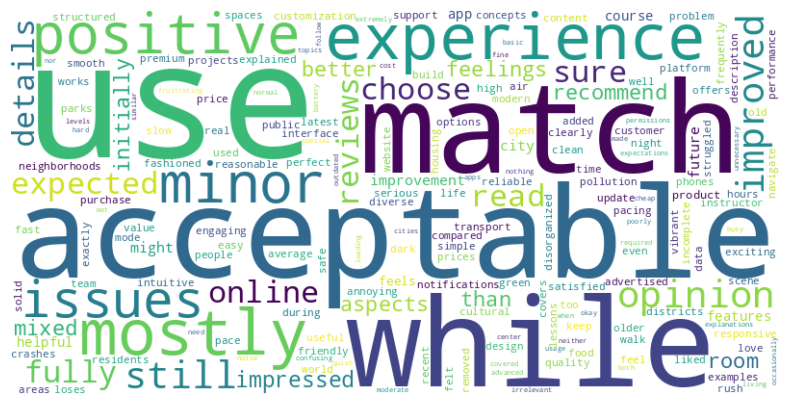

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.show()

In [54]:
def get_words_by_sentiment(df, sentiment):
  all_words=[]

  subset=df[df['sentiment']==sentiment]

  for text in subset['text']:
    words=clean_text(text)
    all_words.extend(words)

  word_counts=Counter(all_words)
  return word_counts

In [55]:
positive_words=get_words_by_sentiment(df,'positive')
negative_words=get_words_by_sentiment(df,'negative')
neutral_words=get_words_by_sentiment(df,'neutral')

In [39]:
print(positive_words)
print(negative_words)
print(neutral_words)

[('use', 67), ('helpful', 51), ('fully', 47), ('match', 47), ('reviews', 47), ('read', 47), ('online', 47), ('might', 44), ('future', 44), ('recommend', 42), ('sure', 41), ('choose', 41), ('better', 40), ('than', 40), ('initially', 40), ('expected', 40), ('opinion', 40), ('still', 40), ('improved', 40), ('city', 40)]
[('mixed', 28), ('feelings', 28), ('aspects', 28), ('experience', 27), ('mostly', 27), ('positive', 27), ('minor', 27), ('issues', 27), ('slow', 26), ('opinion', 26), ('still', 26), ('improved', 26), ('app', 24), ('high', 24), ('details', 23), ('impressed', 23), ('while', 23), ('room', 22), ('improvement', 22), ('acceptable', 22)]
[('acceptable', 44), ('use', 38), ('while', 36), ('match', 34), ('expected', 27), ('sure', 23), ('choose', 23), ('details', 23), ('impressed', 23), ('too', 22), ('experience', 22), ('mostly', 22), ('positive', 22), ('minor', 22), ('issues', 22), ('average', 21), ('compared', 21), ('course', 20), ('city', 20), ('opinion', 20)]


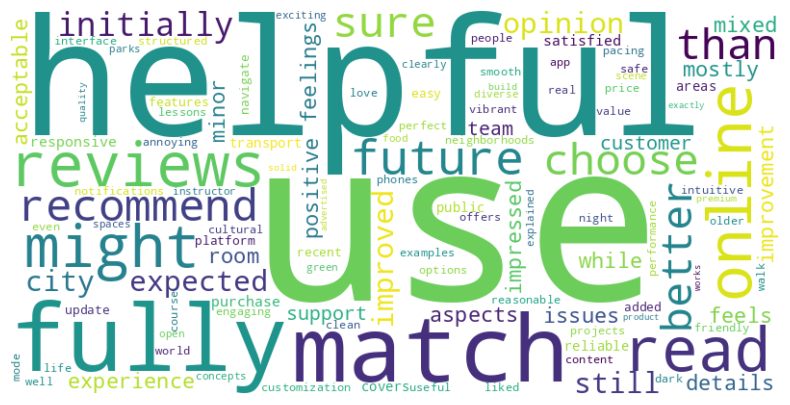

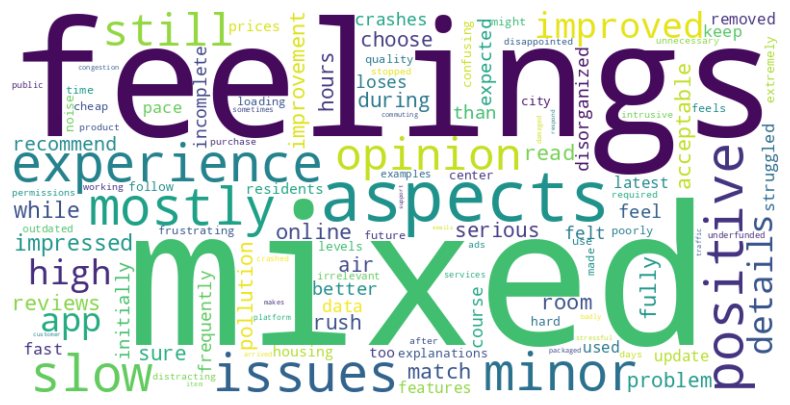

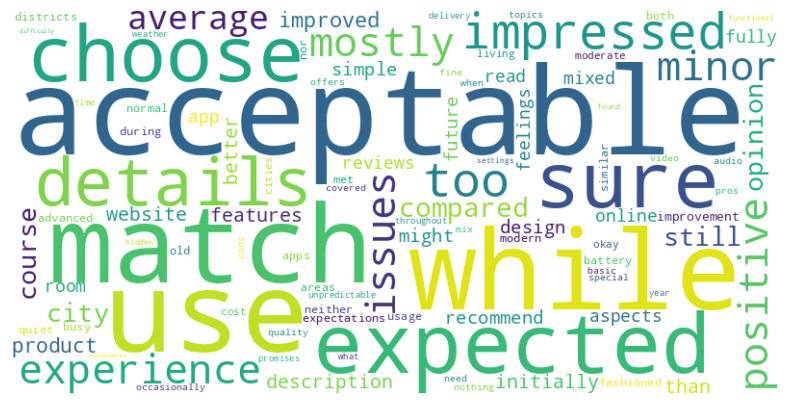

In [57]:
for i in [positive_words,negative_words,neutral_words]:
  wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(i)
  plt.figure(figsize=(10,5))
  plt.imshow(wordcloud,interpolation='bilinear')
  plt.axis('off')
  plt.show()